# Reconnaissance automatique des espèces menacées\n\nProjet AI for Good avec données imaginées.\n\nObjectif : entraîner un modèle capable de reconnaître une espèce menacée probable à partir de caractéristiques observables.

In [10]:
!pip install pandas numpy scikit-learn matplotlib joblib -q

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

## 1. Création de données fictives

In [13]:
profiles = {
    'Panda roux': ('Himalaya', 'forêt tempérée', 'crépusculaire', 'roux et blanc', (50,70), (3,7), (1800,4000), 'en danger'),
    'Tigre de Sumatra': ('Sumatra', 'forêt tropicale', 'nocturne', 'rayures noires', (220,260), (75,140), (0,1200), 'critique'),
    'Gorille des montagnes': ('Afrique centrale', 'forêt montagneuse', 'diurne', 'pelage sombre', (140,180), (70,180), (2200,4300), 'en danger'),
    'Tortue imbriquée': ('océans tropicaux', 'récif corallien', 'diurne', 'carapace écailleuse', (60,100), (40,80), (0,5), 'critique'),
    'Vaquita': ('Golfe de Californie', 'mer côtière', 'diurne', 'gris avec taches', (120,150), (30,55), (0,2), 'critique'),
    'Rhinocéros de Java': ('Java', 'forêt humide', 'crépusculaire', 'peau grise', (300,340), (900,2300), (0,600), 'critique'),
    'Léopard des neiges': ('Asie centrale', 'montagne rocheuse', 'crépusculaire', 'rosettes grises', (160,230), (25,55), (3000,5500), 'vulnérable'),
    'Orang-outan de Bornéo': ('Bornéo', 'forêt tropicale', 'diurne', 'pelage orangé', (110,150), (30,100), (0,1500), 'critique'),
}
rng = np.random.default_rng(42)
rows = []
for species, p in profiles.items():
    region, habitat, activity, pattern, length, weight, altitude, threat = p
    for _ in range(120):
        rows.append({
            'species': species, 'region': region, 'habitat': habitat, 'activity': activity,
            'visual_pattern': pattern, 'threat_level': threat,
            'body_length_cm': round(rng.uniform(*length) + rng.normal(0,4), 2),
            'weight_kg': round(max(0.5, rng.uniform(*weight) + rng.normal(0,2)), 2),
            'altitude_m': round(max(0, rng.uniform(*altitude) + rng.normal(0,80)), 2),
            'temperature_c': round(rng.uniform(5,34), 2),
            'observation_quality': rng.choice(['faible', 'moyenne', 'bonne'], p=[0.15,0.35,0.50])
        })
df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

,species,region,habitat,activity,visual_pattern,threat_level,body_length_cm,weight_kg,altitude_m,temperature_c,observation_quality
0,Léopard des neiges,Asie centrale,montagne rocheuse,crépusculaire,rosettes grises,vulnérable,163.12,52.32,3671.29,22.14,bonne
1,Tortue imbriquée,océans tropicaux,récif corallien,diurne,carapace écailleuse,critique,74.41,66.00,78.23,25.48,faible
2,Gorille des montagnes,Afrique centrale,forêt montagneuse,diurne,pelage sombre,en danger,173.12,92.81,3886.56,18.09,moyenne
3,Orang-outan de Bornéo,Bornéo,forêt tropicale,diurne,pelage orangé,critique,125.61,49.01,796.96,24.12,faible
4,Orang-outan de Bornéo,Bornéo,forêt tropicale,diurne,pelage orangé,critique,133.89,31.79,1432.60,11.17,moyenne


In [14]:
display(df.describe(include='all'))

,species,region,habitat,activity,visual_pattern,threat_level,body_length_cm,weight_kg,altitude_m,temperature_c,observation_quality
count,960,960,960,960,960,960,960.000000,960.000000,960.000000,960.000000,960
unique,8,8,7,3,8,3,NaN,NaN,NaN,NaN,3
top,Léopard des neiges,Asie centrale,forêt tropicale,diurne,rosettes grises,critique,NaN,NaN,NaN,NaN,bonne
freq,120,120,240,480,120,600,NaN,NaN,NaN,NaN,495
mean,NaN,NaN,NaN,NaN,NaN,NaN,164.418802,252.336187,1512.861948,19.552094,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,80.867438,522.427885,1621.736880,8.400002,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,43.220000,0.500000,0.000000,5.020000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,107.535000,40.020000,89.852500,12.087500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,147.170000,62.420000,685.865000,19.710000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,223.817500,111.705000,3042.392500,26.862500,NaN


### 1.1. Visualisation des distributions des caractéristiques

Pour mieux comprendre nos données, nous allons visualiser les distributions de chaque caractéristique.

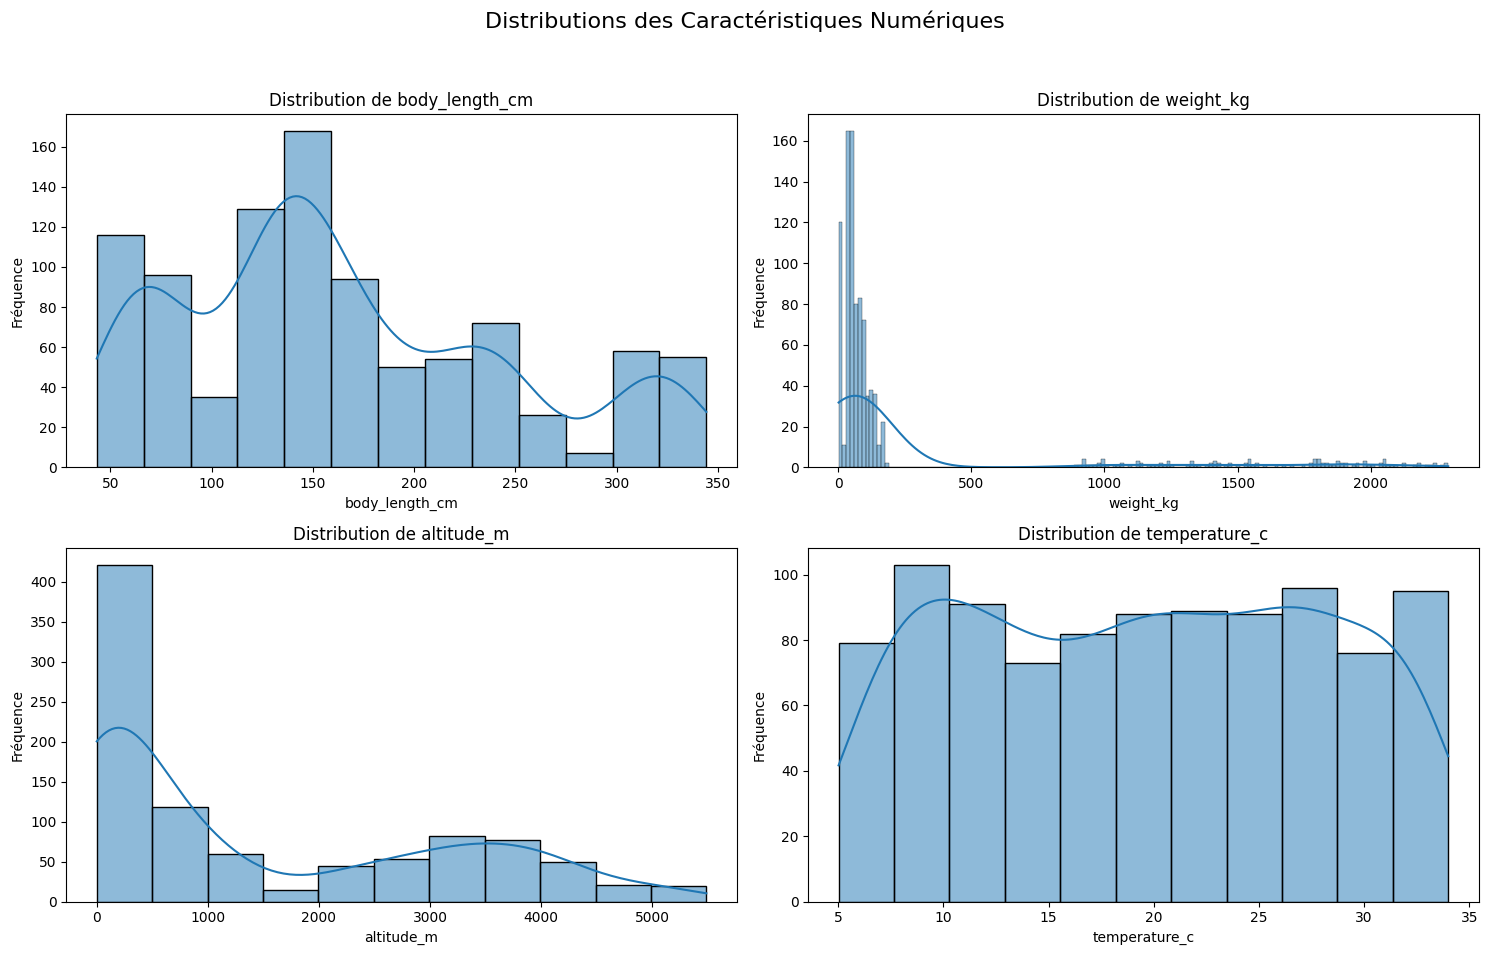

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distributions of numerical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distributions des Caractéristiques Numériques', fontsize=16)

for i, feature in enumerate(['body_length_cm', 'weight_kg', 'altitude_m', 'temperature_c']):
    row = i // 2
    col = i % 2
    sns.histplot(df[feature], kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution de {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Fréquence')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/tmp/ipykernel_2991/4047905660.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[feature], order=df[feature].value_counts().index, ax=axes[i], palette='viridis')
/tmp/ipykernel_2991/4047905660.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[feature], order=df[feature].value_counts().index, ax=axes[i], palette='viridis')
/tmp/ipykernel_2991/4047905660.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[feature], order=df[feature].value_counts().index, ax=axes[i], palette='viridis')
/tmp/ipykernel_2991/4047905660.

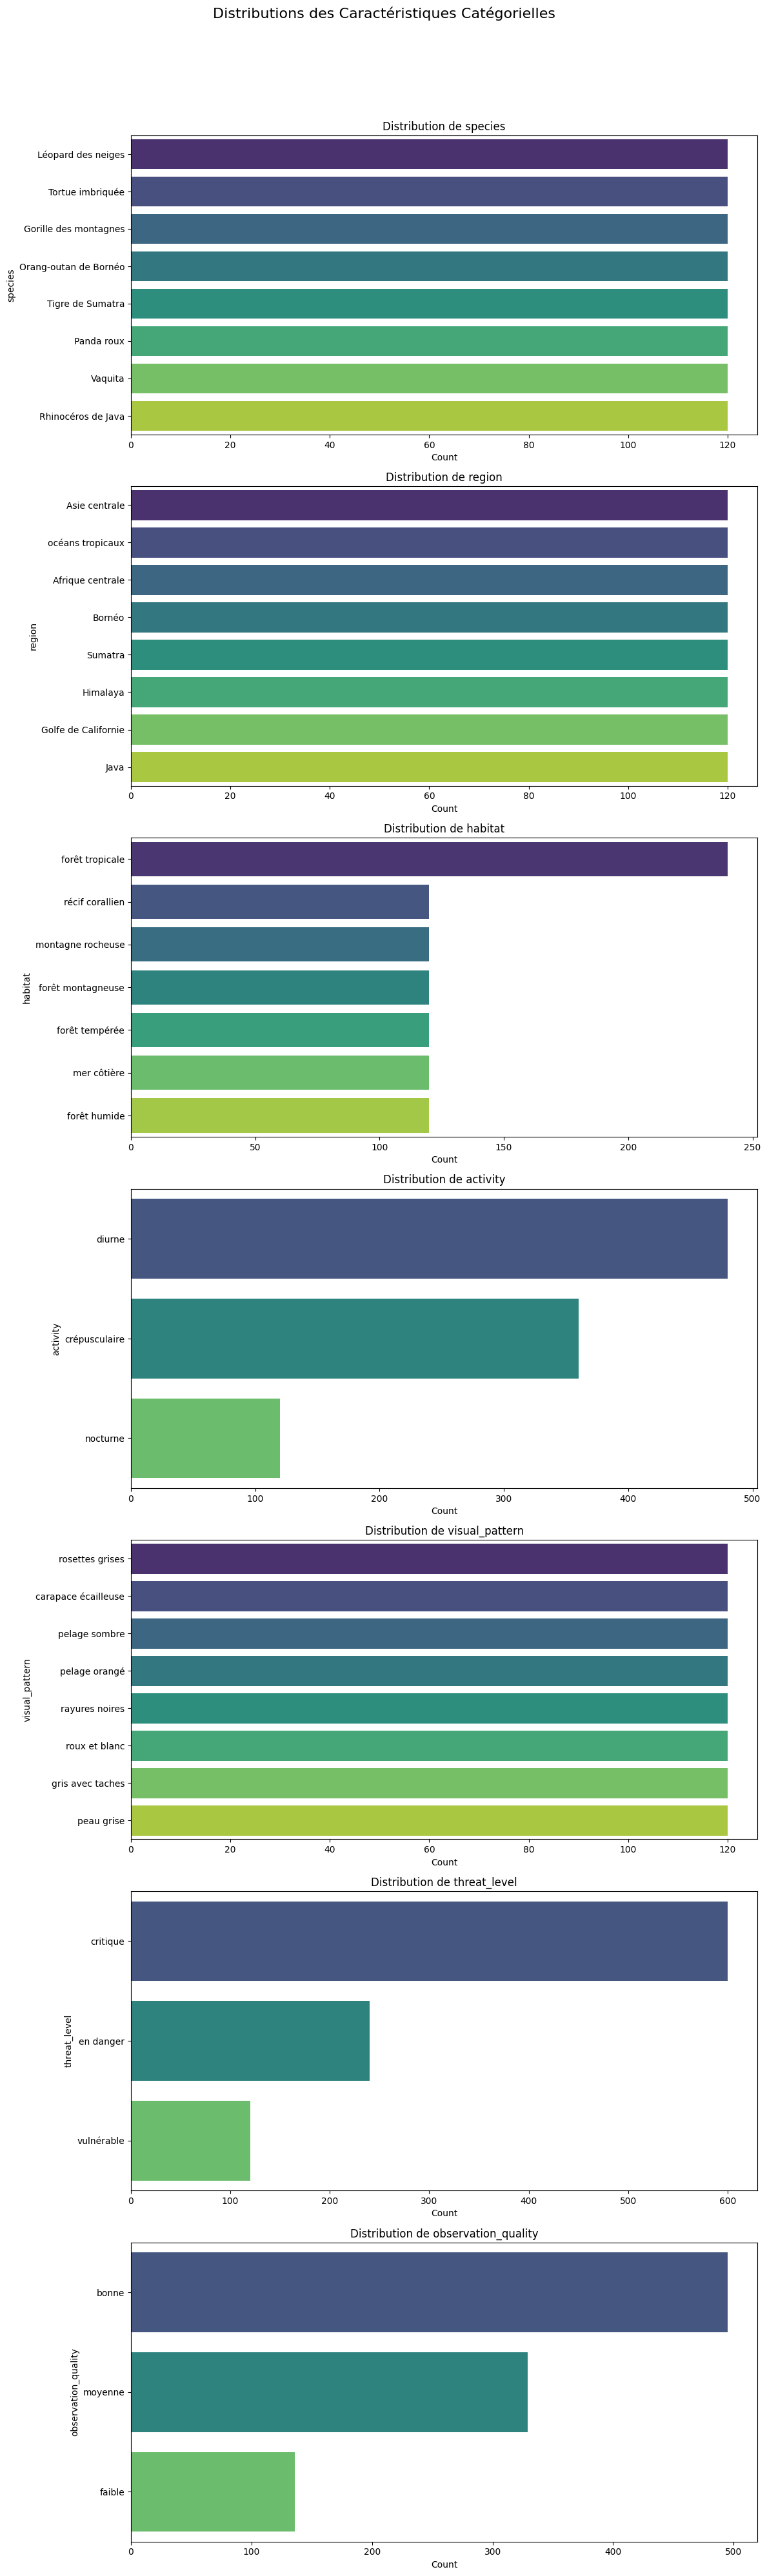

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distributions of categorical features
categorical_features_to_plot = ['species', 'region', 'habitat', 'activity', 'visual_pattern', 'threat_level', 'observation_quality']

fig, axes = plt.subplots(len(categorical_features_to_plot), 1, figsize=(12, 6 * len(categorical_features_to_plot)))
fig.suptitle('Distributions des Caractéristiques Catégorielles', fontsize=16)

for i, feature in enumerate(categorical_features_to_plot):
    sns.countplot(y=df[feature], order=df[feature].value_counts().index, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution de {feature}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(feature)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2. Entraînement du modèle

In [18]:
numeric_features = ['body_length_cm', 'weight_kg', 'altitude_m', 'temperature_c']
categorical_features = ['region', 'habitat', 'activity', 'visual_pattern', 'threat_level', 'observation_quality']
X = df[numeric_features + categorical_features]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))
])
model.fit(X_train, y_train)
preds = model.predict(X_test)
print(classification_report(y_test, preds))

                       precision    recall  f1-score   support

Gorille des montagnes       1.00      1.00      1.00        30
   Léopard des neiges       1.00      1.00      1.00        30
Orang-outan de Bornéo       1.00      1.00      1.00        30
           Panda roux       1.00      1.00      1.00        30
   Rhinocéros de Java       1.00      1.00      1.00        30
     Tigre de Sumatra       1.00      1.00      1.00        30
     Tortue imbriquée       1.00      1.00      1.00        30
              Vaquita       1.00      1.00      1.00        30

             accuracy                           1.00       240
            macro avg       1.00      1.00      1.00       240
         weighted avg       1.00      1.00      1.00       240



## 3. Visualisation

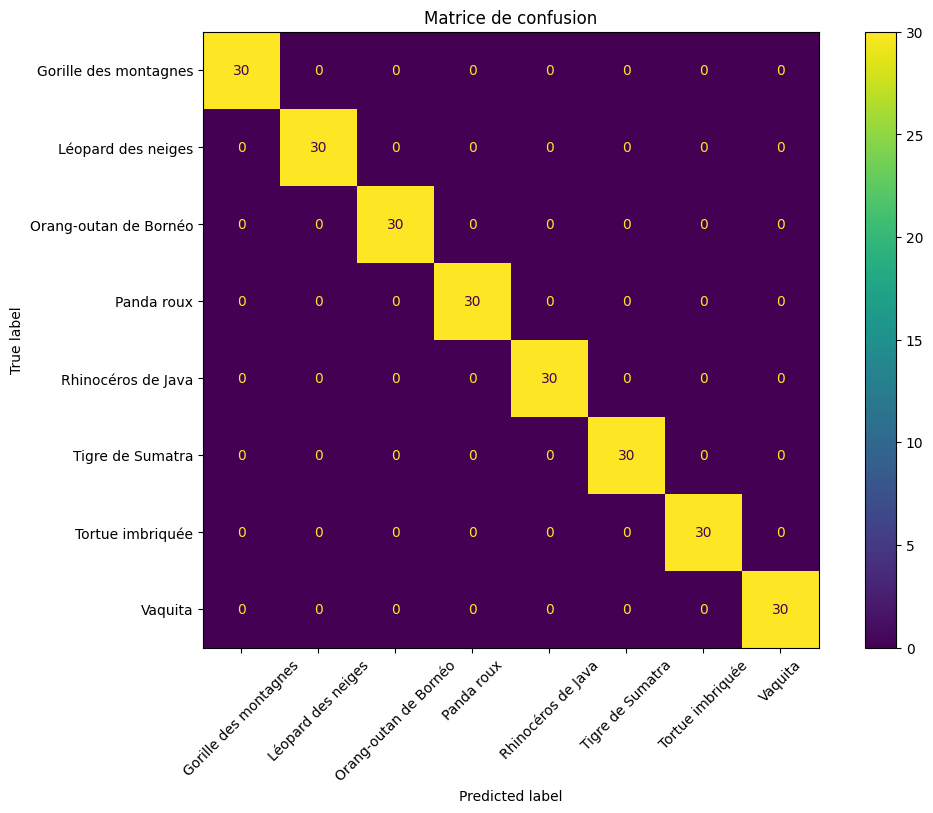

In [20]:
cm = confusion_matrix(y_test, preds, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(12, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Matrice de confusion')
plt.show()

## 4. Prédiction d'une observation

In [22]:
observation = pd.DataFrame([
    {
        'body_length_cm': 185,
        'weight_kg': 42,
        'altitude_m': 4200,
        'temperature_c': 8,
        'region': 'Asie centrale',
        'habitat': 'montagne rocheuse',
        'activity': 'crépusculaire',
        'visual_pattern': 'rosettes grises',
        'threat_level': 'vulnérable',
        'observation_quality': 'bonne',
    }
])
prediction = model.predict(observation)[0]
confidence = model.predict_proba(observation).max()
print('Espèce prédite :', prediction)
print('Confiance :', f'{confidence:.1%}')

Espèce prédite : Léopard des neiges
Confiance : 100.0%


## Note éthique\nPour un vrai projet, il faut protéger les localisations exactes des espèces menacées afin d'éviter le braconnage.